# v4 — модель максимальной энтропии

**Зависимости от других ноутбуков:**
- `02_grid.ipynb` — сетки 1×1 км и границы (`data/processed/grid_*.gpkg`)
- растры населения WorldPop (`pop_*_z.tif`) — готовятся в `02_grid.ipynb`

**Код метода:** `src/spatial_maxent.py`

# Жесткий фокус. Экстремальная концентрация в ядрах агломераций + Сглаженный. Оптимальное «растекание» по транспортной сети и мелким узлам

In [25]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

sys.path.insert(0, '..')

from src.maxent_io import REGIONS, load_region
from src.spatial_maxent import (
    build_cell_features,
    constraint_targets,
    distribute_maxent,
    maxent_weights,
    reference_weights,
)

RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)

# конфигурация для жесткого фокуса
URBAN_ELASTICITY_STRICT = 2.77
ACCESSIBILITY_POWER_STRICT = 0.35

# конфигурация для сглаженного фокуса
URBAN_ELASTICITY_SMOOTH = 1.00
ACCESSIBILITY_POWER_SMOOTH = 0.50

## Метрики

In [26]:
def gini(x):
    x = np.asarray(x, dtype=float)
    x = x[x >= 0]
    if len(x) == 0 or x.sum() == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())


def top_share(x, frac=0.1):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return 0.0
    x_sorted = np.sort(x)[::-1]
    k = max(1, int(len(x_sorted) * frac))
    return x_sorted[:k].sum() / x_sorted.sum()

## 1. Подготовка входов

Собираем `population` и расстояния, сохраняем в `data/processed/grid_*_features.gpkg`.
Повторный запуск читает готовый файл (быстрее).

`FORCE_REBUILD = True`, если обновили сетку или растр.

In [27]:
FORCE_REBUILD = False

grids = {}
for key in REGIONS:
    grid, cfg = load_region(key, force=FORCE_REBUILD)
    grids[key] = (grid, cfg)
    print(f"{cfg.title}: {len(grid):,} ячеек, pop>0: {(grid['population'] > 0).sum():,}")

Московская область: 141,967 ячеек, pop>0: 48,815
Краснодарский край: 185,691 ячеек, pop>0: 20,429
Якутия (центр): 160,801 ячеек, pop>0: 3,061


## 2. Расчёт v4 (maxent)

Cписки параметров

In [28]:
ELASTICITIES = [2.77, 1.00]
POWERS = [0.35, 0.50]
LABELS = ['v4 (строгий)', 'v4 (сглаженный)']
SUFFIXES = ['_strict', '_smooth']

In [29]:
rows = []

for key, (grid, cfg) in grids.items():
    grid = grid.copy()
    for el, pwr, label, suff in zip(ELASTICITIES, POWERS, LABELS, SUFFIXES):
        col_name = f'method_otgr_v4{suff}'
        
        grid[col_name] = distribute_maxent(
            grid,
            cfg.x_otgr,
            urban_elasticity=el,
            accessibility_power=pwr,
        )

        values = grid[col_name].values
        g = gini(values)
        t = top_share(values) * 100
        print(f"{cfg.title} ({label}): Джини {g:.3f}, top-10% {t:.1f}%, сумма {values.sum():.2f} / {cfg.x_otgr}")

        rows.append({
            'Регион': cfg.title,
            'Метод': label,
            'Джини': round(g, 3),
            'Top-10%': f"{t:.1f}%",
            'Сумма': round(float(values.sum()), 2),
            'Ячеек': int((values > 0).sum()),
        })

    grids[key] = (grid, cfg)

maxent_df = pd.DataFrame(rows)
maxent_df

Московская область (v4 (строгий)): Джини 0.993, top-10% 100.0%, сумма 209.00 / 209.0
Московская область (v4 (сглаженный)): Джини 0.924, top-10% 89.6%, сумма 209.00 / 209.0
Краснодарский край (v4 (строгий)): Джини 0.997, top-10% 100.0%, сумма 59.70 / 59.7
Краснодарский край (v4 (сглаженный)): Джини 0.971, top-10% 99.2%, сумма 59.70 / 59.7
Якутия (центр) (v4 (строгий)): Джини 0.999, top-10% 100.0%, сумма 11.20 / 11.2
Якутия (центр) (v4 (сглаженный)): Джини 0.977, top-10% 98.1%, сумма 11.20 / 11.2


,Регион,Метод,Джини,Top-10%,Сумма,Ячеек
0,Московская область,v4 (строгий),0.993,100.0%,209.0,141967
1,Московская область,v4 (сглаженный),0.924,89.6%,209.0,141967
2,Краснодарский край,v4 (строгий),0.997,100.0%,59.7,185691
3,Краснодарский край,v4 (сглаженный),0.971,99.2%,59.7,185691
4,Якутия (центр),v4 (строгий),0.999,100.0%,11.2,160801
5,Якутия (центр),v4 (сглаженный),0.977,98.1%,11.2,160801


## 3. Диагностика: ограничения и λ

In [30]:
for key, (grid, cfg) in grids.items():
    print(f"\n{cfg.title}")
    F, names = build_cell_features(grid)
    
    # таргеты для каждого сценария отдельно
    for el, pwr, label in zip(ELASTICITIES, POWERS, LABELS):
        print(f"  Сценарий: {label} (elasticity={el}, power={pwr})")
        
        w_ref = reference_weights(grid, el, pwr)
        targets = constraint_targets(F, w_ref)
        p = maxent_weights(F, targets)
        achieved = F.T @ p
        
        for name, mu, hat in zip(names, targets, achieved):
            print(f"    {name}: target={mu:.4f}, achieved={hat:.4f}, err={hat - mu:.2e}")


Московская область
  Сценарий: v4 (строгий) (elasticity=2.77, power=0.35)
    log_pop: target=3.2145, achieved=3.2145, err=3.49e-06
    log_access_city: target=3.0445, achieved=3.0445, err=6.15e-07
    log_access_center: target=2.7322, achieved=2.7322, err=5.99e-06
  Сценарий: v4 (сглаженный) (elasticity=1.0, power=0.5)
    log_pop: target=2.5380, achieved=2.5380, err=1.71e-06
    log_access_city: target=2.3651, achieved=2.3651, err=9.20e-07
    log_access_center: target=2.0761, achieved=2.0761, err=3.14e-06

Краснодарский край
  Сценарий: v4 (строгий) (elasticity=2.77, power=0.35)
    log_pop: target=5.1293, achieved=5.1293, err=-1.77e-06
    log_access_city: target=7.7269, achieved=7.7269, err=-2.90e-06
    log_access_center: target=14.8379, achieved=14.8378, err=-4.68e-05
  Сценарий: v4 (сглаженный) (elasticity=1.0, power=0.5)
    log_pop: target=4.4409, achieved=4.4409, err=-5.43e-08
    log_access_city: target=4.0632, achieved=4.0632, err=7.23e-07
    log_access_center: target=7.

## 4. Карты

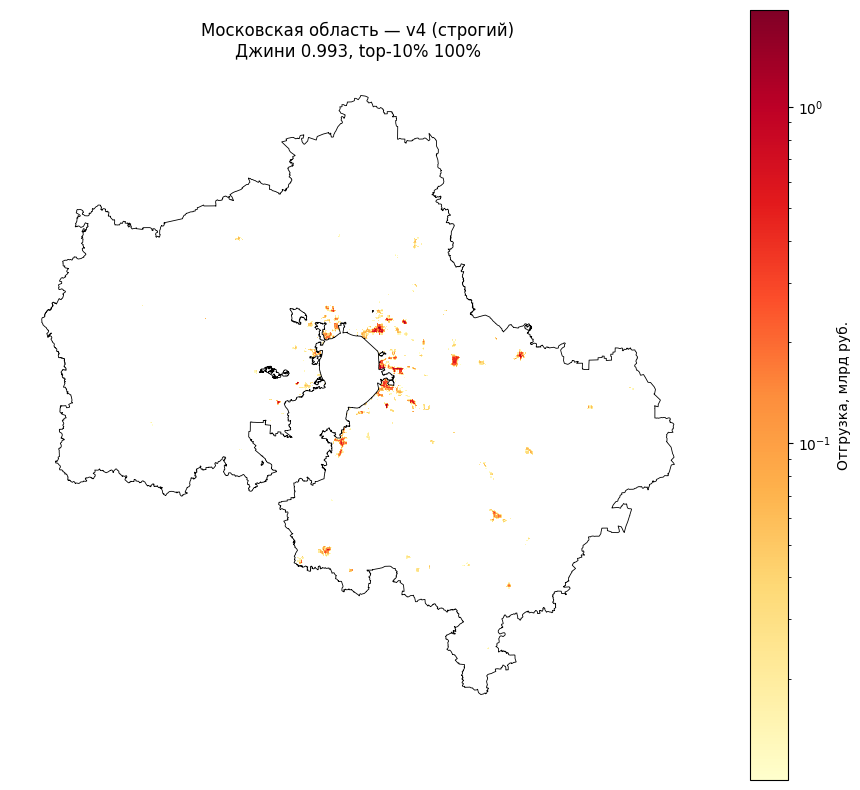

Сохранено: ../results/maxent_mo_strict.png


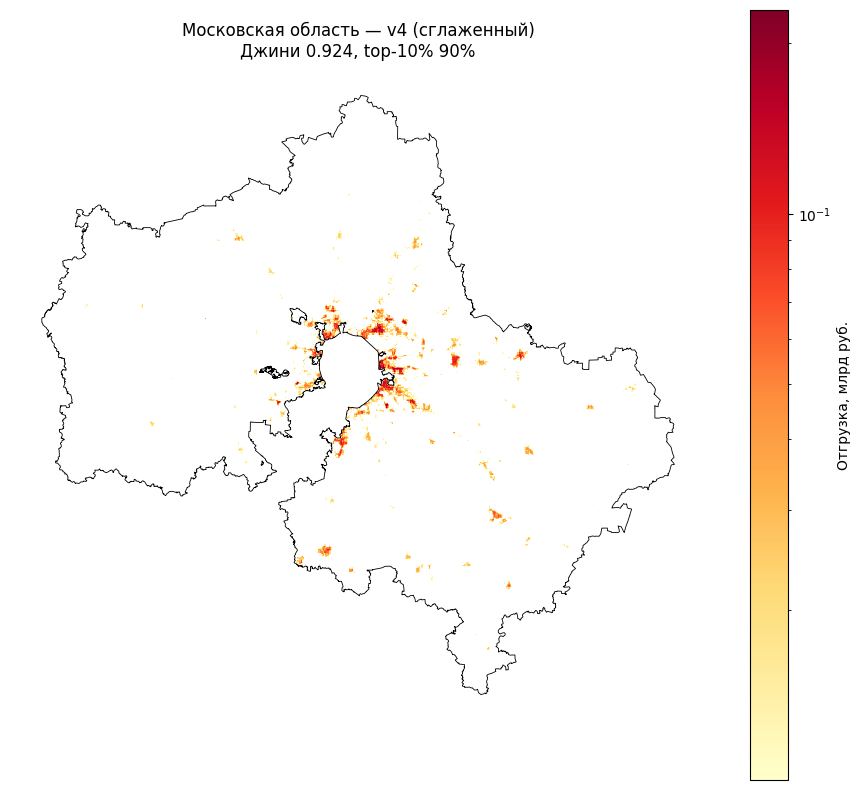

Сохранено: ../results/maxent_mo_smooth.png


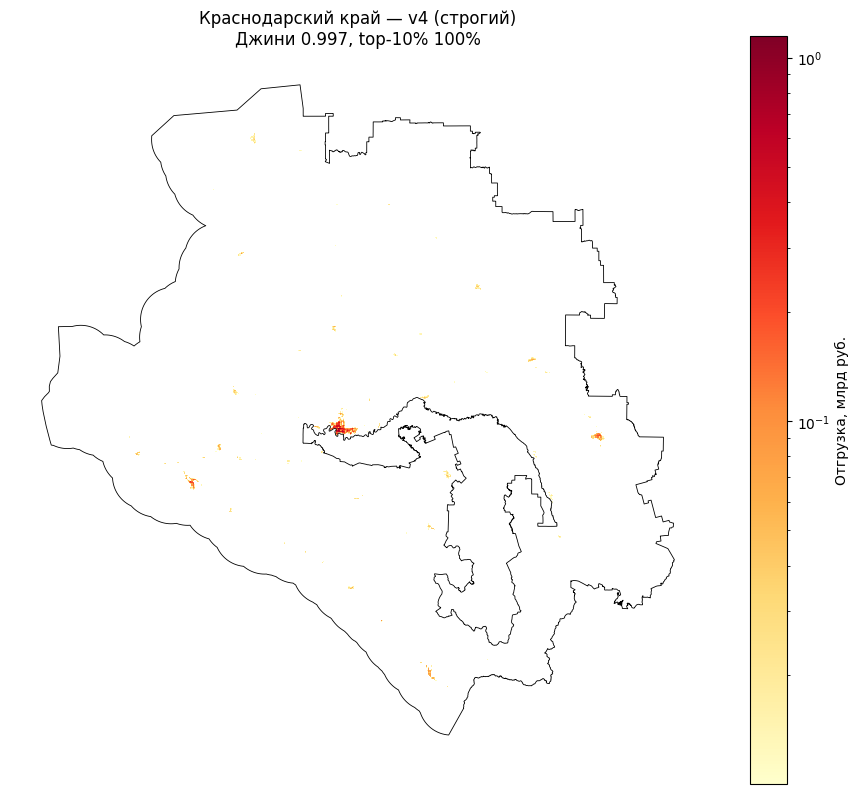

Сохранено: ../results/maxent_kk_strict.png


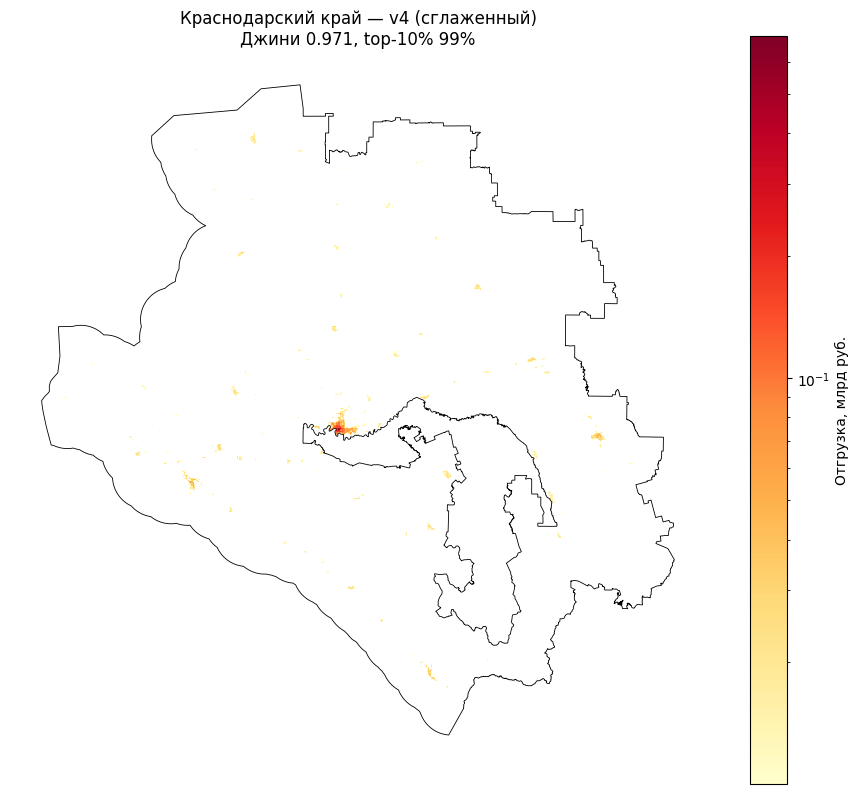

Сохранено: ../results/maxent_kk_smooth.png


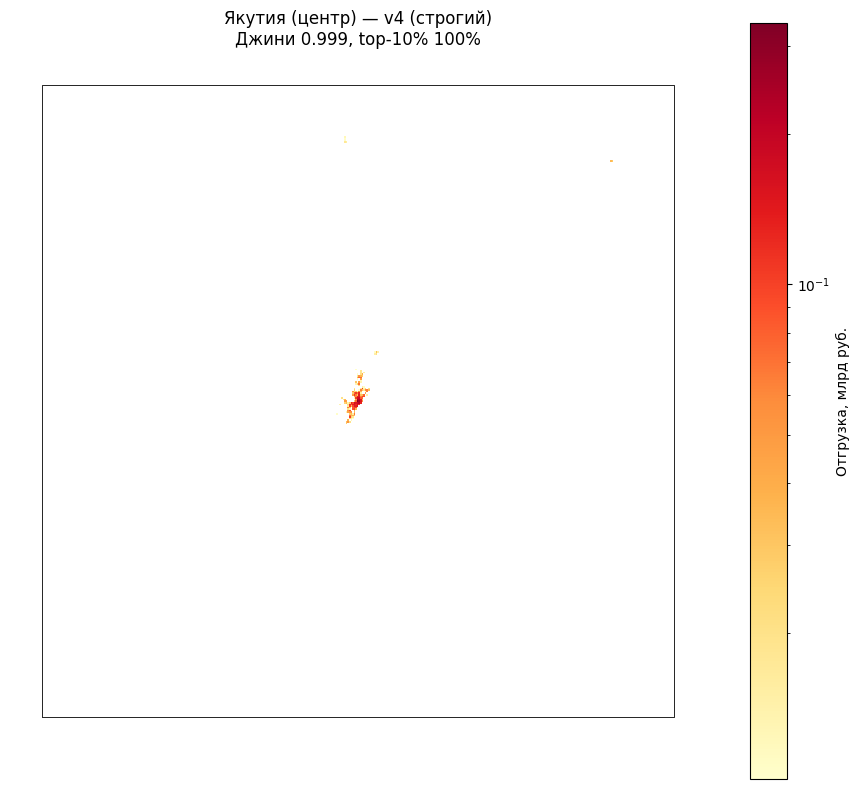

Сохранено: ../results/maxent_ya_strict.png


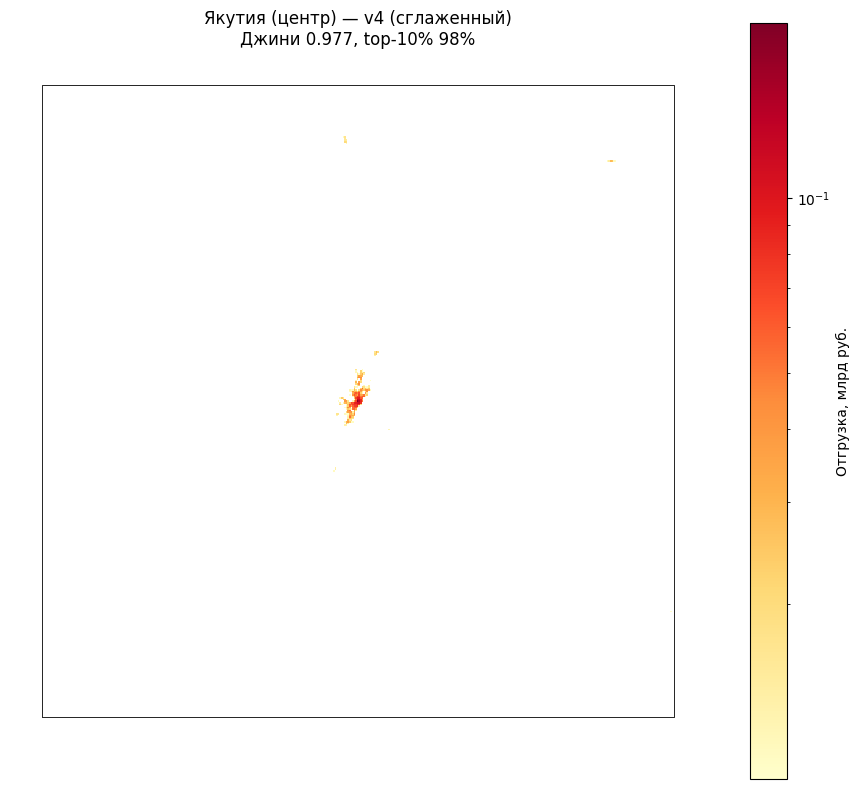

Сохранено: ../results/maxent_ya_smooth.png


In [31]:
def plot_region(grid, cfg, border_path, col_suffix='_strict'):
    col_name = f'method_otgr_v4{col_suffix}' 
    
    border = gpd.read_file(border_path).to_crs(grid.crs)
    
    g = grid[grid[col_name] > 0.01].copy() 
    
    fig, ax = plt.subplots(figsize=(9, 8))
    g.plot(
        column=col_name,
        ax=ax,
        cmap='YlOrRd',
        legend=True,
        norm=mcolors.LogNorm(),
        legend_kwds={'label': 'Отгрузка, млрд руб.'},
    )
    border.boundary.plot(ax=ax, color='black', linewidth=0.6)
    
    vals = grid[col_name].values
    
    label = 'строгий' if col_suffix == '_strict' else 'сглаженный'
    
    ax.set_title(
        f"{cfg.title} — v4 ({label})\n"
        f"Джини {gini(vals):.3f}, top-10% {top_share(vals)*100:.0f}%"
    )
    ax.set_axis_off()
    plt.tight_layout()
    
    out = RESULTS / f"maxent_{cfg.key}{col_suffix}.png"
    plt.savefig(out, dpi=120, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Сохранено: {out}")

for key, (grid, cfg) in grids.items():
    plot_region(grid, cfg, cfg.border_path, col_suffix='_strict')
    plot_region(grid, cfg, cfg.border_path, col_suffix='_smooth')

## 5. Сохранение результатов

- `results/maxent_metrics.csv` — метрики только v4
- `results/maxent_grids/` — сетки с колонкой `method_otgr_v4`
- при наличии `summary_metrics.csv` из `02_grid` — дописывается строка v4

In [32]:
maxent_df.to_csv(RESULTS / 'maxent_metrics.csv', index=False)

out_dir = RESULTS / 'maxent_grids'
out_dir.mkdir(exist_ok=True)
for key, (grid, cfg) in grids.items():
    path = out_dir / f"grid_{cfg.key}_v4.gpkg"
    grid.to_file(path, driver='GPKG')
    print(f"Сохранено: {path}")

summary_path = RESULTS / 'summary_metrics.csv'
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    summary = summary[~summary['Метод'].str.contains('макс. энтропия', na=False)]
    summary = pd.concat([summary, maxent_df], ignore_index=True)
    summary.to_csv(summary_path, index=False)
    print(f"Обновлено: {summary_path}")
else:
    print(f"{summary_path} не найден — сохранены только maxent_metrics.csv")

Сохранено: ../results/maxent_grids/grid_mo_v4.gpkg
Сохранено: ../results/maxent_grids/grid_kk_v4.gpkg
Сохранено: ../results/maxent_grids/grid_ya_v4.gpkg
Обновлено: ../results/summary_metrics.csv


## 6. Таблица для README

In [33]:
df_indexed = maxent_df.set_index(['Метод', 'Регион'])

regions = ['Московская область', 'Краснодарский край', 'Якутия (центр)']

strict_metrics = [f"{df_indexed.loc[('v4 (строгий)', r), 'Джини']} / {df_indexed.loc[('v4 (строгий)', r), 'Top-10%']}" for r in regions]
strict_row = f"| v4 (MaxEnt, строгий) | " + " | ".join(strict_metrics) + " |"

smooth_metrics = [f"{df_indexed.loc[('v4 (сглаженный)', r), 'Джини']} / {df_indexed.loc[('v4 (сглаженный)', r), 'Top-10%']}" for r in regions]
smooth_row = f"| v4 (MaxEnt, сглаженный) | " + " | ".join(smooth_metrics) + " |"

print(strict_row)
print(smooth_row)

| v4 (MaxEnt, строгий) | 0.993 / 100.0% | 0.997 / 100.0% | 0.999 / 100.0% |
| v4 (MaxEnt, сглаженный) | 0.924 / 89.6% | 0.971 / 99.2% | 0.977 / 98.1% |
